# IMS/NASA Bearing Dataset — Live Risk Classification

This notebook builds a live, cross-bearing risk classifier on the IMS/NASA bearing
run-to-failure dataset (Sets 1, 2, 3 — 12 bearings total). The goal mirrors the
project's C-MAPSS work: not a precise RUL number, but an honest, continuously
updating "is this bearing approaching the end of its recorded life?" probability,
validated with leave-one-bearing-out cross-validation.

**Key design decisions (result of extensive iteration, kept here in final form):**
- The risk label is **not** based on which bearings had a documented failure mode.
  Every bearing's recording ends at some point (failure or otherwise), so the label
  is simply "is this row in the last 5% of this bearing's own recorded lifetime?" —
  applied identically to all 12 bearings.
- Features are **rolling-smoothed** (raw instantaneous values are noisy) and
  **normalized to each bearing's own early-life baseline** (raw magnitudes differ
  by up to ~2.7x across bearings due to rig/mounting differences — without this,
  a model trained on one bearing's absolute scale fails badly on another's).
- Evaluation is **leave-one-bearing-out** (12 folds) — never row-level splitting.

## 1. Setup & Data Loading

In [1]:
import os
import time
import pickle
import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kurtosis as kurtosis_func, spearmanr
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
BASE_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw', 'nasabearing')

set1_dir = os.path.join(BASE_DIR, "1st_test", "1st_test")
set2_dir = os.path.join(BASE_DIR, "2nd_test", "2nd_test")
set3_dir = os.path.join(BASE_DIR, "3rd_test", "4th_test", "txt")

set1_cols = ['B1_x', 'B1_y', 'B2_x', 'B2_y', 'B3_x', 'B3_y', 'B4_x', 'B4_y']
set23_cols = ['B1_x', 'B2_x', 'B3_x', 'B4_x']

def list_data_files(folder):
    return sorted(f for f in os.listdir(folder) if not f.startswith('.'))

files_set1 = list_data_files(set1_dir)
files_set2 = list_data_files(set2_dir)
files_set3 = list_data_files(set3_dir)

print(f"Set 1: {len(files_set1)} files | Set 2: {len(files_set2)} files | Set 3: {len(files_set3)} files")

Set 1: 2156 files | Set 2: 984 files | Set 3: 6324 files


## 2. Feature Extraction

Seven time-domain statistical features per file, computed on the X-axis channel of
each bearing (chosen for consistency across sets — Set 1 has both X/Y, Sets 2/3
have X only). These are standard vibration-analysis features from the bearing
diagnostics literature (RMS, crest/clearance/shape/impulse factors, kurtosis,
Shannon entropy).

In [2]:
def compute_rms(x):
    return np.sqrt(np.mean(x**2))

def crest_factor(x):
    rms = compute_rms(x)
    return np.max(np.abs(x)) / rms if rms > 0 else 0.0

def clearance_factor(x):
    sqrt_abs_mean = np.mean(np.sqrt(np.abs(x)))
    denom = sqrt_abs_mean ** 2
    return np.max(np.abs(x)) / denom if denom > 0 else 0.0

def shape_factor(x):
    rms = compute_rms(x)
    mean_abs = np.mean(np.abs(x))
    return rms / mean_abs if mean_abs > 0 else 0.0

def impulse_factor(x):
    mean_abs = np.mean(np.abs(x))
    return np.max(np.abs(x)) / mean_abs if mean_abs > 0 else 0.0

def shannon_entropy(x, bins=500):
    hist, _ = np.histogram(x, bins=bins)
    hist = hist[hist > 0]
    p = hist / hist.sum()
    return -np.sum(p * np.log(p))

def extract_features_for_set(set_dir, files, bearing_cols, set_name):
    print(f"{set_name}: extracting features from {len(files)} files...")
    start = time.time()
    records = []
    for i, fname in enumerate(files):
        df = pd.read_csv(os.path.join(set_dir, fname), sep='\t', header=None, names=bearing_cols)
        row = {'file_idx': i}
        for col in bearing_cols:
            x = df[col].values
            row[f'{col}_rms'] = compute_rms(x)
            row[f'{col}_crest'] = crest_factor(x)
            row[f'{col}_kurtosis'] = kurtosis_func(x)
            row[f'{col}_entropy'] = shannon_entropy(x)
            row[f'{col}_clearance'] = clearance_factor(x)
            row[f'{col}_shape'] = shape_factor(x)
            row[f'{col}_impulse'] = impulse_factor(x)
        records.append(row)
        if i % 1000 == 0:
            print(f"  {i}/{len(files)}  ({time.time()-start:.0f}s elapsed)")
    print(f"  done in {time.time()-start:.0f}s\n")
    return pd.DataFrame(records)

set1_full = extract_features_for_set(set1_dir, files_set1, set1_cols, "Set 1")
set2_full = extract_features_for_set(set2_dir, files_set2, set23_cols, "Set 2")
set3_full = extract_features_for_set(set3_dir, files_set3, set23_cols, "Set 3")

set1_full.to_csv(os.path.join(BASE_DIR, 'set1_full_features.csv'), index=False)
set2_full.to_csv(os.path.join(BASE_DIR, 'set2_full_features.csv'), index=False)
set3_full.to_csv(os.path.join(BASE_DIR, 'set3_full_features.csv'), index=False)

Set 1: extracting features from 2156 files...
  0/2156  (0s elapsed)
  1000/2156  (10s elapsed)
  2000/2156  (19s elapsed)
  done in 21s

Set 2: extracting features from 984 files...
  0/984  (0s elapsed)
  done in 5s

Set 3: extracting features from 6324 files...
  0/6324  (0s elapsed)
  1000/6324  (6s elapsed)
  2000/6324  (11s elapsed)
  3000/6324  (16s elapsed)
  4000/6324  (21s elapsed)
  5000/6324  (27s elapsed)
  6000/6324  (35s elapsed)
  done in 37s



## 3. Pooling All 12 Bearings

Each bearing's data (using its X-axis channel) is combined into a single long
table, tagged with a `bearing_id` (e.g. `S1_B3`) and a `RUL` column (cycles
remaining until *that bearing's own* last recorded file — not tied to failure
labels).

In [3]:
def build_bearing_df(df, bearing_col_prefix, set_name, bearing_short_name):
    d = df.copy()
    n = len(d)
    d['RUL'] = n - d['file_idx'] - 1
    d['bearing_id'] = f"{set_name}_{bearing_short_name}"
    feat_types = ['rms', 'crest', 'kurtosis', 'entropy', 'clearance', 'shape', 'impulse']
    rename_map = {f'{bearing_col_prefix}_{ft}': ft for ft in feat_types}
    d = d.rename(columns=rename_map)
    return d[['file_idx', 'RUL', 'bearing_id'] + feat_types]

all_bearings = []
for b in ['B1', 'B2', 'B3', 'B4']:
    all_bearings.append(build_bearing_df(set1_full, f'{b}_x', 'S1', b))
    all_bearings.append(build_bearing_df(set2_full, f'{b}_x', 'S2', b))
    all_bearings.append(build_bearing_df(set3_full, f'{b}_x', 'S3', b))

pooled_12 = pd.concat(all_bearings, ignore_index=True)
bearing_ids = sorted(pooled_12['bearing_id'].unique())

pooled_12['max_file_idx'] = pooled_12.groupby('bearing_id')['file_idx'].transform('max')
pooled_12['life_pct'] = 100 * pooled_12['file_idx'] / pooled_12['max_file_idx']

print(f"Total rows: {len(pooled_12)} | Bearings: {len(bearing_ids)}")
print(bearing_ids)
pooled_12.to_csv(os.path.join(BASE_DIR, 'pooled_12_bearings.csv'), index=False)

Total rows: 37856 | Bearings: 12
['S1_B1', 'S1_B2', 'S1_B3', 'S1_B4', 'S2_B1', 'S2_B2', 'S2_B3', 'S2_B4', 'S3_B1', 'S3_B2', 'S3_B3', 'S3_B4']


## 4. Feature Engineering: Rolling Mean + Baseline Normalization

Two transformations, applied to all 7 raw features:
1. **Rolling mean** (20-file window) — smooths instantaneous noise.
2. **Baseline normalization** — divide by the bearing's own mean over its first
   10% of recorded life. This converts an absolute magnitude (which varies up to
   ~2.7x across bearings due to rig/mounting differences) into a *relative*
   multiple of that bearing's own healthy state — the key fix that made
   cross-bearing generalization possible.

In [4]:
def normalize_by_baseline(df, feat, baseline_frac=0.1):
    df = df.copy()
    baselines = {}
    for bid, g in df.groupby('bearing_id'):
        g = g.sort_values('file_idx')
        n_baseline = max(int(len(g) * baseline_frac), 20)
        baselines[bid] = g[feat].iloc[:n_baseline].dropna().mean()
    df[f'{feat}_norm'] = df.apply(
        lambda r: r[feat] / baselines[r['bearing_id']] if baselines[r['bearing_id']] > 0 else 1.0, axis=1
    )
    return df

all_feat_names = ['rms', 'crest', 'kurtosis', 'entropy', 'clearance', 'shape', 'impulse']

pooled_12 = pooled_12.sort_values(['bearing_id', 'file_idx']).reset_index(drop=True)
for feat in all_feat_names:
    pooled_12[f'{feat}_rm'] = pooled_12.groupby('bearing_id')[feat].transform(
        lambda x: x.rolling(20, min_periods=5).mean()
    )
    pooled_12 = normalize_by_baseline(pooled_12, f'{feat}_rm')

norm_cols = [f'{feat}_rm_norm' for feat in all_feat_names]
pooled_valid = pooled_12.dropna(subset=norm_cols).copy()
print(f"Rows with valid rolling features: {len(pooled_valid)} / {len(pooled_12)}")

Rows with valid rolling features: 37808 / 37856


## 5. Feature Selection: Within-Bearing Trend Correlation

For each of the 7 normalized features, we measure how consistently it trends
with time *within each bearing* (Spearman correlation vs. `file_idx`, computed
separately per bearing, then averaged). This avoids the classic pooled-correlation
artifact where a feature looks strong only because of between-bearing differences.

In [5]:
trend_summary = {}
for feat in norm_cols:
    per_bearing = {}
    for bid, g in pooled_valid.groupby('bearing_id'):
        r, _ = spearmanr(g['file_idx'], g[feat])
        per_bearing[bid] = r
    trend_summary[feat] = per_bearing

trend_df = pd.DataFrame(trend_summary).T
trend_df['mean_abs_corr'] = trend_df.abs().mean(axis=1)
trend_df['pct_bearings_same_direction'] = trend_df.iloc[:, :12].apply(
    lambda row: max((row > 0).sum(), (row < 0).sum()) / 12, axis=1
)
print(trend_df[['mean_abs_corr', 'pct_bearings_same_direction']]
      .sort_values('mean_abs_corr', ascending=False).round(3).to_string())

                   mean_abs_corr  pct_bearings_same_direction
rms_rm_norm                0.643                        0.917
entropy_rm_norm            0.554                        0.833
kurtosis_rm_norm           0.424                        0.583
shape_rm_norm              0.410                        0.667
crest_rm_norm              0.370                        0.583
clearance_rm_norm          0.360                        0.500
impulse_rm_norm            0.348                        0.500


### 5.1 Selected Features: RMS + Kurtosis

RMS is the strongest and most consistent feature (mean |r|≈0.64, same direction
in 11/12 bearings). Several combinations were tested empirically (RMS+entropy,
RMS+kurtosis+entropy) — RMS+Kurtosis gave the best leave-one-out F1 score despite
kurtosis's slightly weaker raw correlation, likely because it carries complementary
(non-redundant) information relative to RMS. This is the final feature set.

In [6]:
feature_cols = ['rms_rm_norm', 'kurtosis_rm_norm']
print("Final feature set:", feature_cols)

Final feature set: ['rms_rm_norm', 'kurtosis_rm_norm']


## 6. Risk Label: Last 5% of Own Recorded Life

Applied identically to all 12 bearings, independent of documented failure cause —
a bearing's recording ending (for any reason) means it is, by definition,
approaching RUL=0. Several thresholds (15%, 10%, 5%) were tested; 5% gives the
sharpest, most actionable definition of "critical."

In [7]:
RISK_THRESHOLD_PCT = 5
pooled_valid['risk_label'] = (pooled_valid['life_pct'] >= (100 - RISK_THRESHOLD_PCT)).astype(int)

print("Positive rate per bearing:")
print(pooled_valid.groupby('bearing_id')['risk_label'].mean().round(4))

Positive rate per bearing:
bearing_id
S1_B1    0.0502
S1_B2    0.0502
S1_B3    0.0502
S1_B4    0.0502
S2_B1    0.0510
S2_B2    0.0510
S2_B3    0.0510
S2_B4    0.0510
S3_B1    0.0502
S3_B2    0.0502
S3_B3    0.0502
S3_B4    0.0502
Name: risk_label, dtype: float64


## 7. Leave-One-Bearing-Out Classification

Random Forest classifier, trained on 11 bearings and evaluated on the 12th,
repeated for all 12 bearings — no bearing is ever in both train and test.

In [8]:
loo_results = []
all_true, all_pred = [], []

for test_id in bearing_ids:
    train = pooled_valid[pooled_valid['bearing_id'] != test_id]
    test = pooled_valid[pooled_valid['bearing_id'] == test_id]

    clf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                                   min_samples_leaf=5, class_weight='balanced')
    clf.fit(train[feature_cols], train['risk_label'])
    pred = clf.predict(test[feature_cols])

    loo_results.append({
        'bearing': test_id, 'n': len(test),
        'accuracy': round(accuracy_score(test['risk_label'], pred), 3),
        'precision': round(precision_score(test['risk_label'], pred, zero_division=0), 3),
        'recall': round(recall_score(test['risk_label'], pred, zero_division=0), 3),
    })
    all_true.extend(test['risk_label'].tolist())
    all_pred.extend(pred.tolist())

loo_df = pd.DataFrame(loo_results)
print(loo_df.to_string(index=False))

print(f"\n=== OVERALL (pooled across 12 folds) ===")
print(f"Accuracy:  {accuracy_score(all_true, all_pred):.3f}")
print(f"Precision: {precision_score(all_true, all_pred):.3f}")
print(f"Recall:    {recall_score(all_true, all_pred):.3f}")
print(f"F1:        {f1_score(all_true, all_pred):.3f}")
print(f"\nConfusion matrix:\n{confusion_matrix(all_true, all_pred)}")

bearing    n  accuracy  precision  recall
  S1_B1 2152     0.547      0.035   0.306
  S1_B2 2152     0.952      1.000   0.037
  S1_B3 2152     0.860      0.034   0.065
  S1_B4 2152     0.598      0.111   1.000
  S2_B1  980     0.755      0.172   1.000
  S2_B2  980     0.936      0.442   1.000
  S2_B3  980     0.969      0.625   1.000
  S2_B4  980     0.936      0.427   0.760
  S3_B1 6320     0.929      0.327   0.394
  S3_B2 6320     0.971      1.000   0.413
  S3_B3 6320     0.503      0.090   0.978
  S3_B4 6320     0.803      0.177   0.804

=== OVERALL (pooled across 12 folds) ===
Accuracy:  0.797
Precision: 0.144
Recall:    0.611
F1:        0.233

Confusion matrix:
[[28983  6925]
 [  739  1161]]


## 8. Visualizing Every Bearing: Where Does the Model Alarm?

For each of the 12 bearings, its leave-one-out model's predicted risk probability
is plotted over time, with the true risk region (last 5% of life) shaded. This
reveals what the aggregate metrics hide: roughly half the bearings show the
intended "quiet early, sharp late alarm" behavior; the rest are noisier.

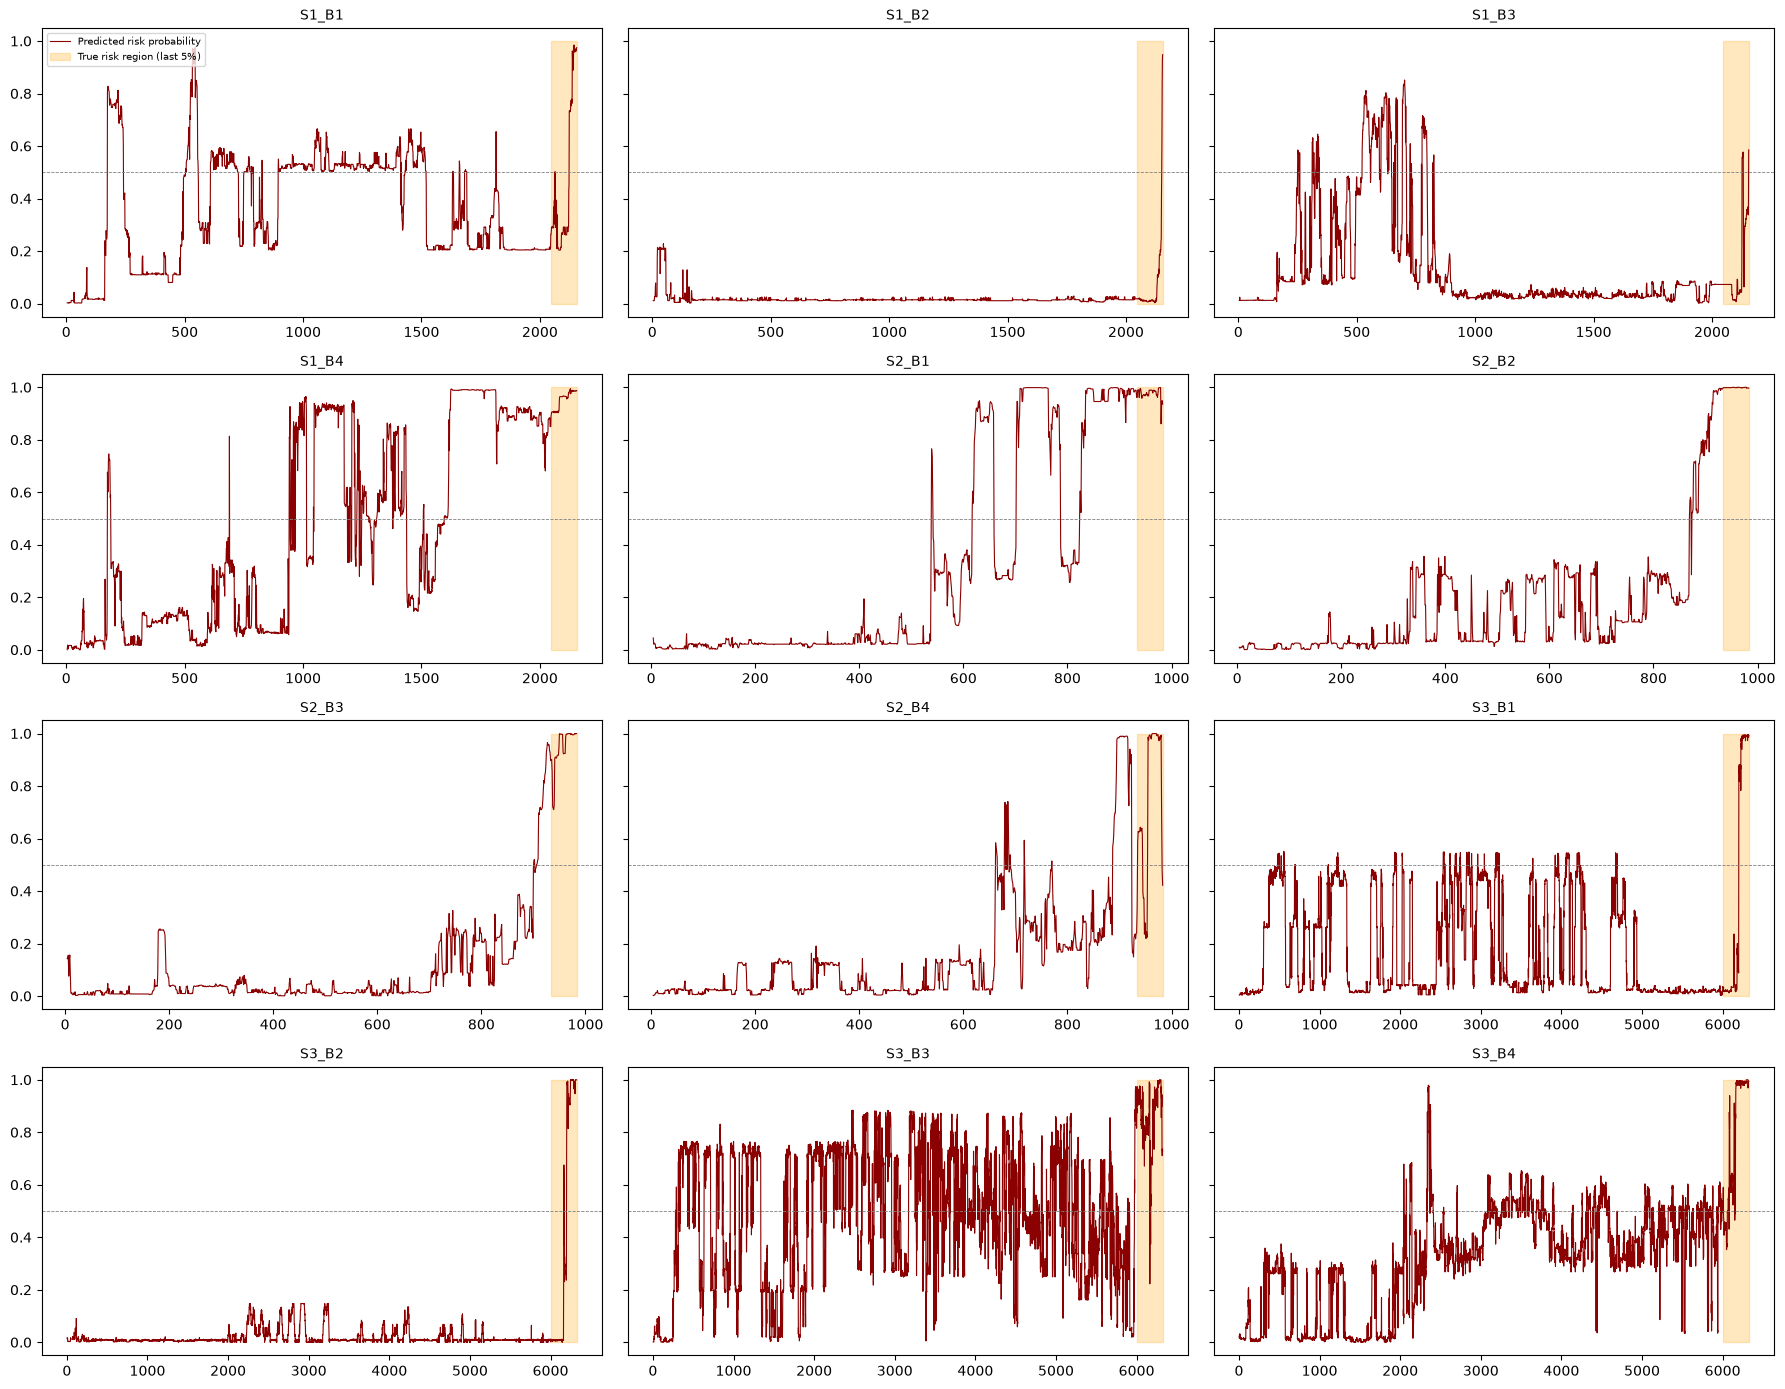

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(18, 14), sharey=True)
axes = axes.flatten()

for idx, test_id in enumerate(bearing_ids):
    train = pooled_valid[pooled_valid['bearing_id'] != test_id]
    test = pooled_valid[pooled_valid['bearing_id'] == test_id].sort_values('file_idx')

    clf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                                   min_samples_leaf=5, class_weight='balanced')
    clf.fit(train[feature_cols], train['risk_label'])
    proba = clf.predict_proba(test[feature_cols])[:, 1]

    ax = axes[idx]
    ax.plot(test['file_idx'], proba, color='darkred', linewidth=0.8, label='Predicted risk probability')
    ax.fill_between(test['file_idx'], 0, 1, where=(test['risk_label'] == 1).values,
                     color='orange', alpha=0.25, label='True risk region (last 5%)')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.6)
    ax.set_title(test_id, fontsize=10)
    ax.set_ylim(-0.05, 1.05)

axes[0].legend(fontsize=7, loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'all_bearings_risk_grid.png'), dpi=100)
plt.show()

## 9. Average Template & Synthetic Stream Sanity Check

Instead of picking one real bearing as a synthetic-stream template (which would
inherit that bearing's specific quirks), we build a single "prototype" curve by
resampling all 12 bearings onto a common 0-100% life-percentage axis and
averaging — this is what the live dashboard's synthetic generator will be built
on.

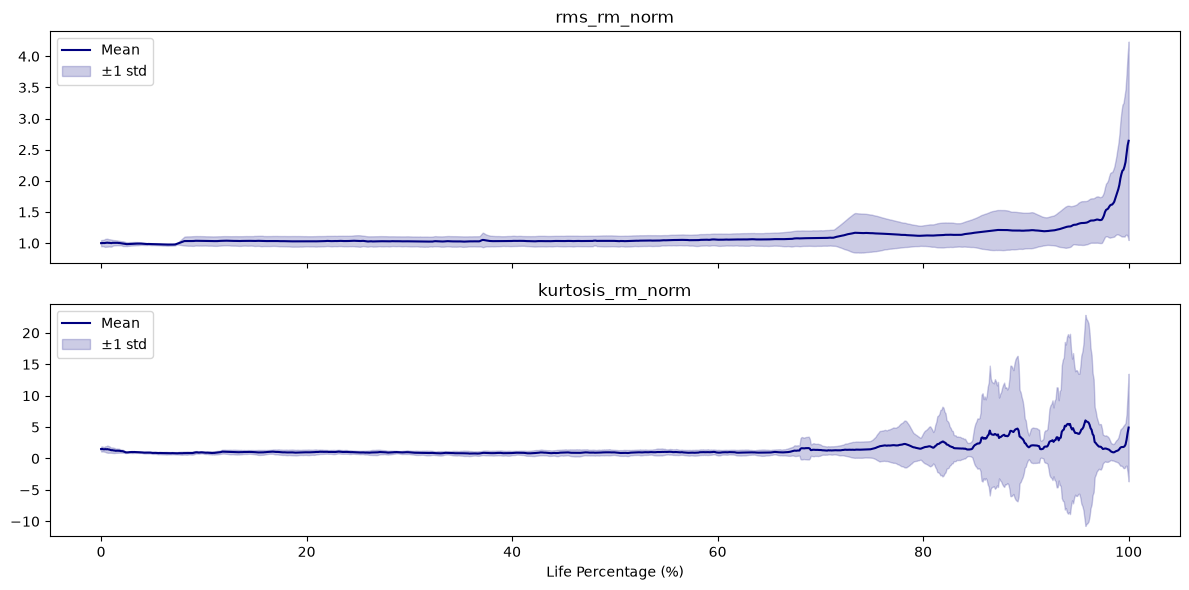

In [10]:
def build_average_template(pooled_df, feat_cols, n_points=1000):
    common_pct = np.linspace(0, 100, n_points)
    curves = {c: [] for c in feat_cols}
    for bid, g in pooled_df.groupby('bearing_id'):
        g = g.sort_values('file_idx')
        life_pct = 100 * g['file_idx'] / g['file_idx'].max()
        for c in feat_cols:
            vals = g[c].values
            valid = ~np.isnan(vals)
            curves[c].append(np.interp(common_pct, life_pct[valid], vals[valid]))
    avg_t = pd.DataFrame({'life_pct': common_pct})
    std_t = pd.DataFrame({'life_pct': common_pct})
    for c in feat_cols:
        stacked = np.array(curves[c])
        avg_t[c] = stacked.mean(axis=0)
        std_t[c] = stacked.std(axis=0)
    return avg_t, std_t

avg_template, std_template = build_average_template(pooled_valid, feature_cols)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for i, col in enumerate(feature_cols):
    axes[i].plot(avg_template['life_pct'], avg_template[col], color='navy', label='Mean')
    axes[i].fill_between(avg_template['life_pct'],
                          avg_template[col] - std_template[col],
                          avg_template[col] + std_template[col],
                          alpha=0.2, color='navy', label='\u00b11 std')
    axes[i].set_title(col)
    axes[i].legend()
axes[-1].set_xlabel('Life Percentage (%)')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'average_template.png'), dpi=100)
plt.show()

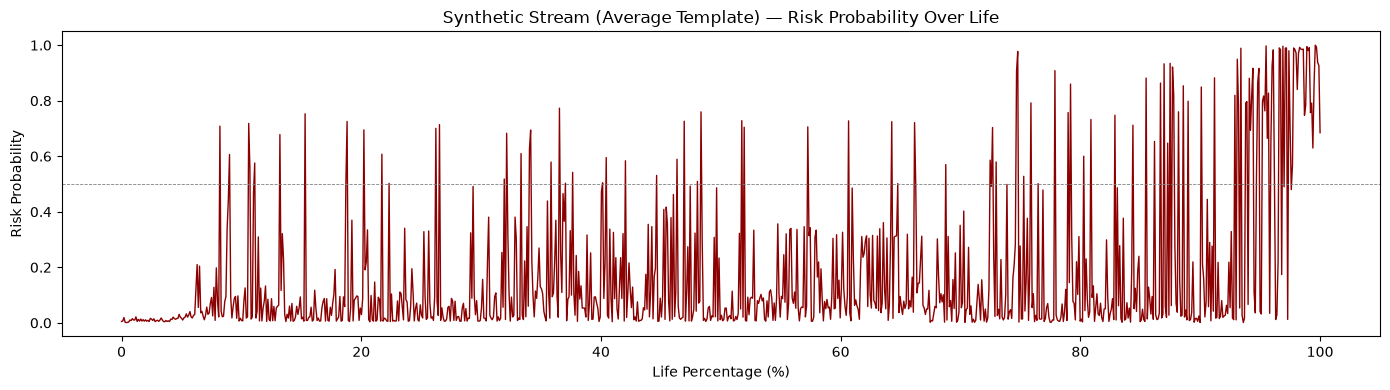

Risk probability at 10% life:  0.009
Risk probability at 50% life:  0.027
Risk probability at 80% life:  0.013
Risk probability at 99% life:  0.991


In [11]:
# Final production model: trained on ALL 12 bearings (no holdout - this is what ships)
final_clf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                                     min_samples_leaf=5, class_weight='balanced')
final_clf.fit(pooled_valid[feature_cols], pooled_valid['risk_label'])

def generate_synthetic_from_template(avg_t, std_t, feat_cols, n_points=1000, noise_scale=0.3, seed=None):
    rng = np.random.default_rng(seed)
    synth = pd.DataFrame({'life_pct': avg_t['life_pct'], 'file_idx': range(n_points)})
    for c in feat_cols:
        noise = rng.normal(0, std_t[c].values * noise_scale)
        synth[c] = avg_t[c].values + noise
    return synth

synth = generate_synthetic_from_template(avg_template, std_template, feature_cols, seed=7)
proba_synth = final_clf.predict_proba(synth[feature_cols])[:, 1]

plt.figure(figsize=(14, 4))
plt.plot(synth['life_pct'], proba_synth, color='darkred', linewidth=1)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.6)
plt.xlabel('Life Percentage (%)')
plt.ylabel('Risk Probability')
plt.title('Synthetic Stream (Average Template) \u2014 Risk Probability Over Life')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'synthetic_avg_template_risk.png'), dpi=100)
plt.show()

print(f"Risk probability at 10% life:  {proba_synth[100]:.3f}")
print(f"Risk probability at 50% life:  {proba_synth[500]:.3f}")
print(f"Risk probability at 80% life:  {proba_synth[800]:.3f}")
print(f"Risk probability at 99% life:  {proba_synth[990]:.3f}")

## 10. Save Final Model & Metadata

Raw data (~7GB across all three sets) is intentionally **not** committed to the
repo — only the trained model, the average/std templates (for synthetic stream
generation), and a metadata report documenting known limitations.

In [12]:
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

with open(os.path.join(MODELS_DIR, 'bearing_model.pkl'), 'wb') as f:
    pickle.dump(final_clf, f)

avg_template.to_csv(os.path.join(MODELS_DIR, 'bearing_avg_template.csv'), index=False)
std_template.to_csv(os.path.join(MODELS_DIR, 'bearing_std_template.csv'), index=False)

metadata = {
    "dataset": "IMS/NASA Bearing Dataset (Sets 1, 2, 3 - 12 bearings)",
    "data_source_note": "Raw data (~7GB) not included in repo; see README for download link",
    "created": datetime.now().isoformat(),
    "n_bearings": 12,
    "feature_columns": feature_cols,
    "feature_engineering": {
        "rolling_window": 20,
        "baseline_normalization_frac": 0.1,
        "note": "raw stat -> 20-file rolling mean -> divided by bearing's own first-10%-of-life mean"
    },
    "risk_threshold_pct": RISK_THRESHOLD_PCT,
    "risk_definition": "Last 5% of a bearing's own recorded lifetime, regardless of documented failure cause",
    "performance": {
        "leave_one_bearing_out_12fold": {
            "accuracy": round(accuracy_score(all_true, all_pred), 3),
            "precision": round(precision_score(all_true, all_pred), 3),
            "recall": round(recall_score(all_true, all_pred), 3),
            "f1": round(f1_score(all_true, all_pred), 3),
        },
        "note": "Performance is highly bearing-dependent - see per-bearing grid (Section 8). Roughly half the bearings show clean early-quiet/late-alarm behavior; the rest are noisier throughout."
    },
    "known_limitations": [
        "n=12 bearings total; only 4 have a documented failure mode",
        "Risk label reflects 'end of recorded life', not verified physical failure for every bearing",
        "Feature-model reliability varies substantially by bearing (see Section 8 grid)",
    ]
}
with open(os.path.join(MODELS_DIR, 'bearing_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print(" -", os.path.join(MODELS_DIR, 'bearing_model.pkl'))
print(" -", os.path.join(MODELS_DIR, 'bearing_avg_template.csv'))
print(" -", os.path.join(MODELS_DIR, 'bearing_std_template.csv'))
print(" -", os.path.join(MODELS_DIR, 'bearing_metadata.json'))

Saved:
 - /Users/erenosma/Downloads/predictive-maintenance-dashboard/predictive-maintenance-dashboard/models/bearing_model.pkl
 - /Users/erenosma/Downloads/predictive-maintenance-dashboard/predictive-maintenance-dashboard/models/bearing_avg_template.csv
 - /Users/erenosma/Downloads/predictive-maintenance-dashboard/predictive-maintenance-dashboard/models/bearing_std_template.csv
 - /Users/erenosma/Downloads/predictive-maintenance-dashboard/predictive-maintenance-dashboard/models/bearing_metadata.json
